# IRI

Check IRI seasonal forecast

In [18]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [221]:
import calendar

import ocha_stratus as stratus
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from src.datasources import iri, codab
from src.utils.blob_utils import PROJECT_PREFIX
from src.utils import rp_calc

## Load and process data

In [33]:
codab.download_codab_to_blob()

In [34]:
adm = codab.load_codab_from_blob()

<Axes: >

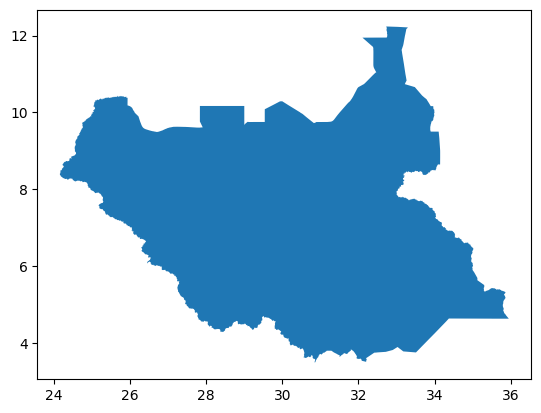

In [35]:
adm.plot()

In [20]:
ds_iri = iri.load_raw_iri()

In [21]:
ds_iri

<xarray.Dataset> Size: 621MB
Dimensions:  (L: 4, C: 3, I-C: 15, F: 99, X: 361, Y: 181)
Coordinates:
  * L        (L) float32 16B 1.0 2.0 3.0 4.0
    C        (C, I-C) int8 45B ...
  * F        (F) object 792B 2017-02-16 00:00:00 ... 2025-04-16 00:00:00
  * X        (X) float32 1kB -180.0 -179.0 -178.0 -177.0 ... 178.0 179.0 180.0
  * Y        (Y) float32 724B 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
Dimensions without coordinates: I-C
Data variables:
    prob     (F, L, C, Y, X) float64 621MB ...

In [22]:
da_season = ds_iri.sel(F=ds_iri.F[ds_iri.F.dt.month == 4], L=3).isel(C=-1)[
    "prob"
]

In [23]:
da_season

<xarray.DataArray 'prob' (F: 9, Y: 181, X: 361)> Size: 5MB
[588069 values with dtype=float64]
Coordinates:
    L        float32 4B 3.0
  * F        (F) object 72B 2017-04-16 00:00:00 ... 2025-04-16 00:00:00
  * X        (X) float32 1kB -180.0 -179.0 -178.0 -177.0 ... 178.0 179.0 180.0
  * Y        (Y) float32 724B 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
Attributes: (12/13)
    pointwidth:      1
    defaultvalue:    783.5
    units:           percent
    long_name:       Tercile Probability
    expires:         1747180800
    colorscalename:  tercileclassesscale
    ...              ...
    CE:              100
    scale_min:       0.0
    CS:              0
    ncolor:          254
    scale_max:       100.0
    maxncolor:       254

In [26]:
blob_name = f"{PROJECT_PREFIX}/raw/ssd_watershed.zip"

In [27]:
gdf_shed = stratus.load_shp_from_blob(blob_name)

<Axes: >

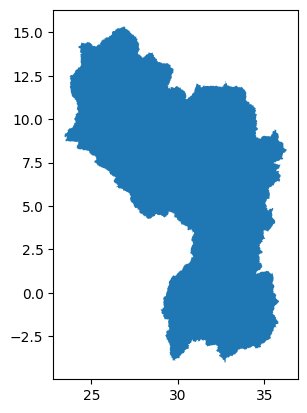

In [29]:
gdf_shed.plot()

In [37]:
blob_name = f"{PROJECT_PREFIX}/raw/ssd_rivers.zip"

In [38]:
gdf_rivers = stratus.load_shp_from_blob(blob_name)

<Axes: >

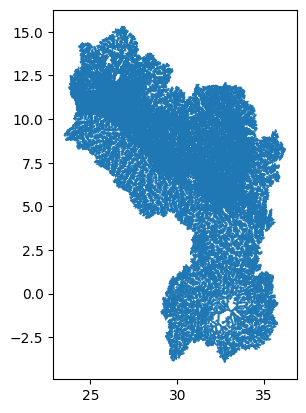

In [39]:
gdf_rivers.plot()

<Axes: >

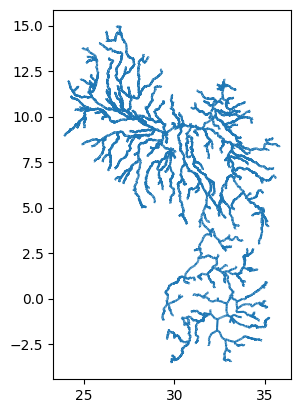

In [49]:
gdf_rivers[gdf_rivers["sorder"] > 3].plot()

In [52]:
da_season = da_season.rio.write_crs(4326)

In [60]:
def upsample_dataarray(
    da: xr.DataArray, resolution: float = 0.1
) -> xr.DataArray:
    new_lat = np.arange(da.Y.min() - 1, da.Y.max() + 1, resolution)
    new_lon = np.arange(da.X.min() - 1, da.X.max() + 1, resolution)
    return da.interp(
        Y=new_lat,
        X=new_lon,
        method="nearest",
        kwargs={"fill_value": "extrapolate"},
    )

In [72]:
# clip before upsample to save memory
da_clip = da_season.rio.clip(gdf_shed.geometry, all_touched=True)
da_clip_up = upsample_dataarray(da_clip)

/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_54401/2122970780.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  new_lat = np.arange(da.Y.min() - 1, da.Y.max() + 1, resolution)
/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_54401/2122970780.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  new_lon = np.arange(da.X.min() - 1, da.X.max() + 1, resolution)


In [73]:
da_clip_up_clip = da_clip_up.rio.clip(gdf_shed.geometry)

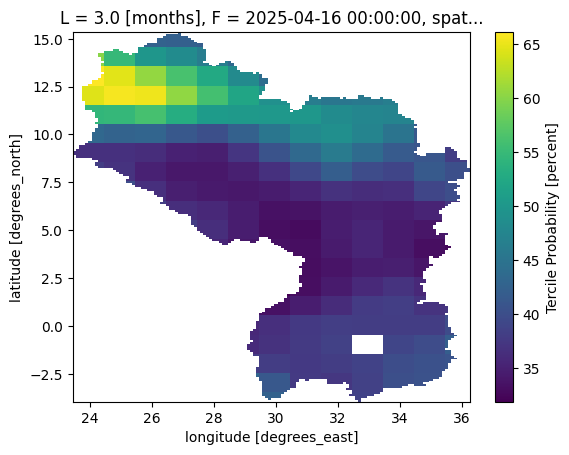

In [78]:
da_clip_up_clip.isel(F=-1).plot()

## Plotting

### Watershed-level current forecast

Text(0.5, 1.0, 'IRI forecast issued 2025-04-16 for JAS,\nover watershed of White Nile at exit from South Sudan')

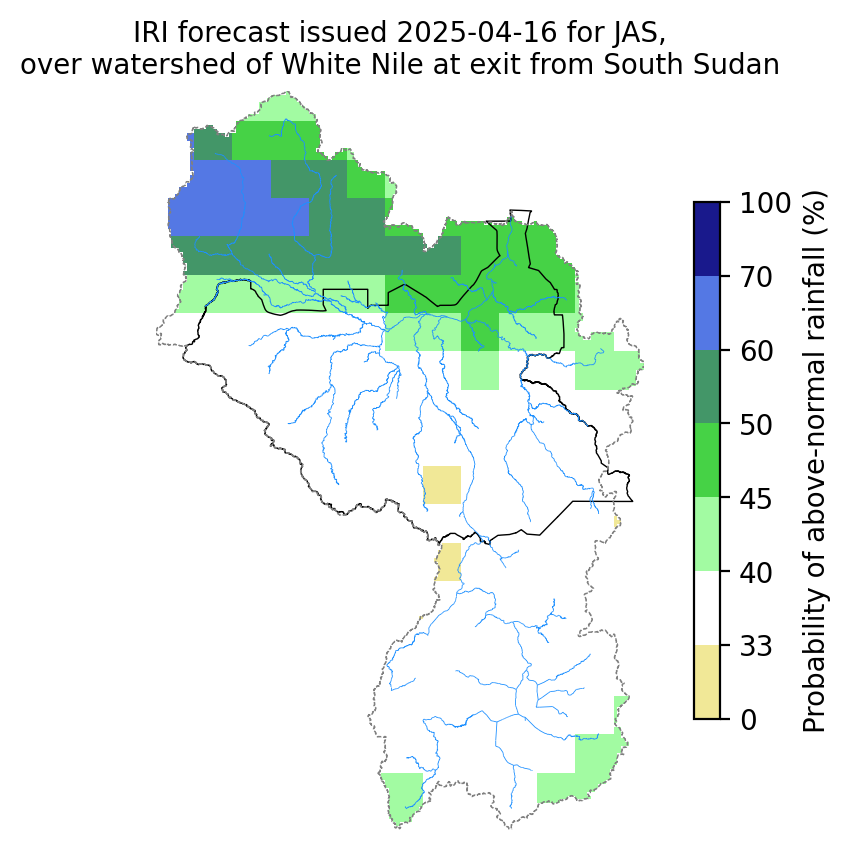

In [328]:
# Define your color boundaries and corresponding colors
bounds = [0, 33, 40, 45, 50, 60, 70, 100]  # Add 0 and 100 to cover full range
colors = [
    "khaki",
    "white",
    "palegreen",
    "limegreen",
    "seagreen",
    "royalblue",
    "navy",
]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

da_plot = da_clip_up_clip.isel(F=-1)

fig, ax = plt.subplots(dpi=200)
adm.boundary.plot(ax=ax, linewidth=0.5, color="k")
da_plot.plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    alpha=0.9,
    cbar_kwargs={
        "label": "Probability of above-normal rainfall (%)",
        "shrink": 0.7,
    },
)
gdf_shed.boundary.plot(ax=ax, linewidth=0.5, color="grey", linestyle="--")
gdf_rivers[gdf_rivers["sorder"] > 4].plot(
    ax=ax, linewidth=0.3, color="dodgerblue"
)

valid_months_str = "".join(
    [
        calendar.month_abbr[
            int(da_plot.F.dt.month) + x + int(da_plot.L.values)
        ][0]
        for x in range(3)
    ]
)
issued_date_str = str(da_plot.F.values).split(" ")[0]

ax.axis("off")
ax.set_title(
    f"IRI forecast issued {issued_date_str} "
    f"for {valid_months_str},\n"
    "over watershed of White Nile at exit from South Sudan",
    fontsize=10,
)

### Mean over watershed per year

In [300]:
da_mean = da_clip_up_clip.mean(dim=["X", "Y"])

In [316]:
df_iri = da_mean.to_dataframe()["prob"].reset_index()
df_iri["year"] = df_iri["F"].astype(str).str[:4].astype(int)
df_iri["issued_month"] = df_iri["F"].astype(str).str[5:7].astype(int)
df_iri

,F,prob,year,issued_month
0,2017-04-16 00:00:00,34.534072,2017,4
1,2018-04-16 00:00:00,37.916119,2018,4
2,2019-04-16 00:00:00,40.639787,2019,4
3,2020-04-16 00:00:00,42.113795,2020,4
4,2021-04-16 00:00:00,46.949645,2021,4
5,2022-04-16 00:00:00,38.839630,2022,4
6,2023-04-16 00:00:00,33.921862,2023,4
7,2024-04-16 00:00:00,40.882030,2024,4
8,2025-04-16 00:00:00,40.848027,2025,4


In [317]:
df_iri = rp_calc.calculate_one_group_rp(
    df_iri, ascending=False, col_name="prob"
)

In [318]:
df_iri

,F,prob,year,issued_month,prob_rank,prob_rp
0,2017-04-16 00:00:00,34.534072,2017,4,8.0,1.250000
1,2018-04-16 00:00:00,37.916119,2018,4,7.0,1.428571
2,2019-04-16 00:00:00,40.639787,2019,4,5.0,2.000000
3,2020-04-16 00:00:00,42.113795,2020,4,2.0,5.000000
4,2021-04-16 00:00:00,46.949645,2021,4,1.0,10.000000
5,2022-04-16 00:00:00,38.839630,2022,4,6.0,1.666667
6,2023-04-16 00:00:00,33.921862,2023,4,9.0,1.111111
7,2024-04-16 00:00:00,40.882030,2024,4,3.0,3.333333
8,2025-04-16 00:00:00,40.848027,2025,4,4.0,2.500000


In [320]:
issued_mo_str = calendar.month_abbr[df_iri.iloc[0]["issued_month"]]

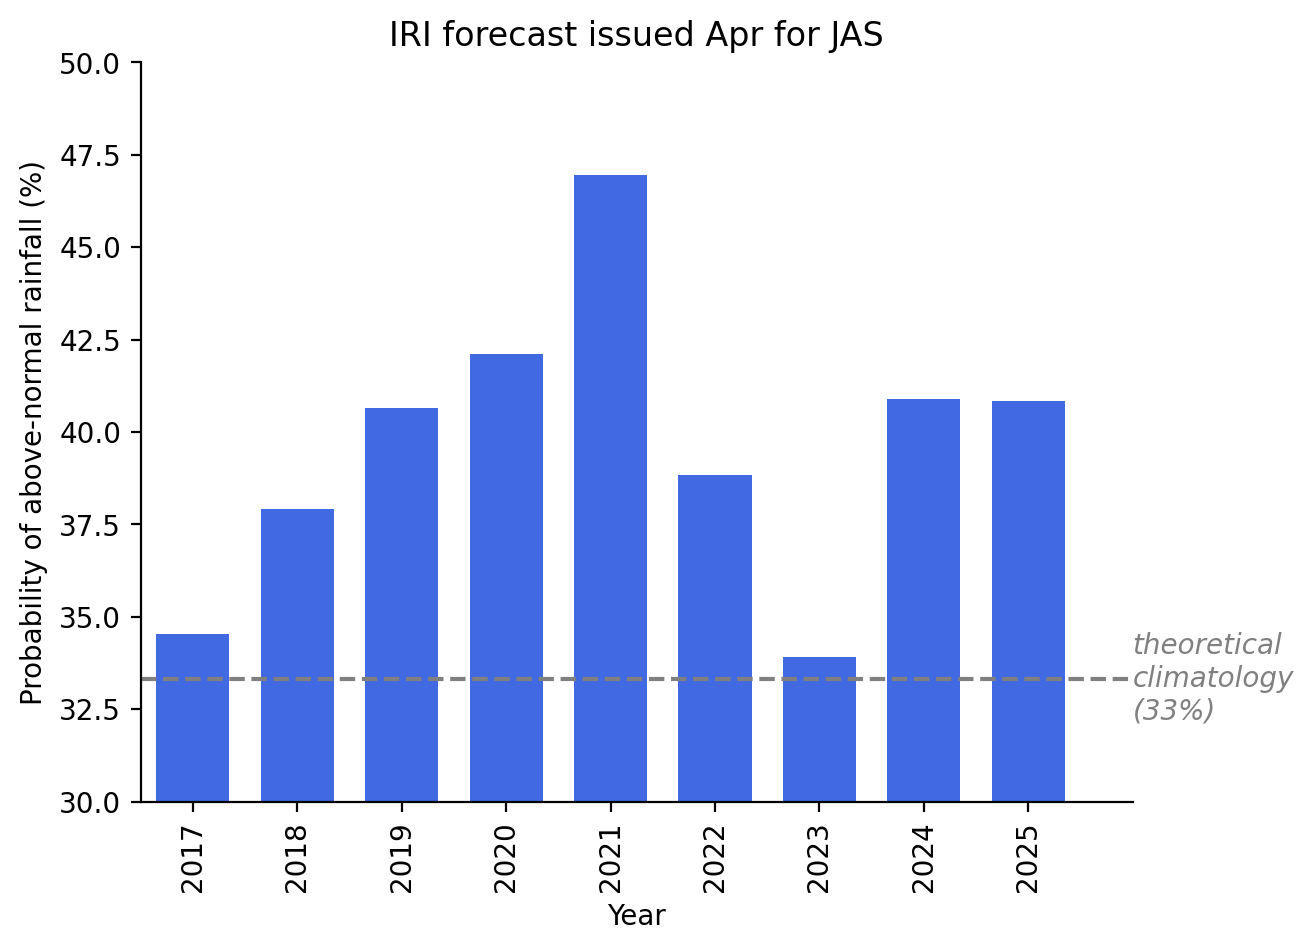

In [327]:
fig, ax = plt.subplots(dpi=200)
df_iri.plot(
    x="year",
    y="prob",
    ax=ax,
    legend=False,
    kind="bar",
    width=0.7,
    color="royalblue",
)
ax.axhline(33.333, color="grey", linestyle="--")
ax.annotate(
    "theoretical\nclimatology\n(33%)",
    # (df_iri["year"].max() + 1, 33),
    (len(df_iri), 33.333),
    va="center",
    fontstyle="italic",
    color="grey",
)

# ax.set_xlim(left=df_iri["year"].min(), right=df_iri["year"].max() + 1)
ax.set_xlim(left=-0.5, right=len(df_iri))
ax.set_ylim(top=50, bottom=30)

ax.set_xlabel("Year")
ax.set_ylabel("Probability of above-normal rainfall (%)")
ax.set_title(f"IRI forecast issued {issued_mo_str} " f"for {valid_months_str}")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)